<a href="https://colab.research.google.com/github/IrvanVillagerCode/Driver_Drowsiness_Detection_MobileNetV2_uas/blob/main/Copy_of_Driver_Drowsiness_Detection_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Driver Drowsiness Detection — CNN MobileNetV2
## Project Akhir Pengolahan Citra — Universitas Pelita Bangsa 2026

**Kelompok:**
- Agnes Dwetasari (312410092)
- Bagas Meriko Handika (312410459)
- Irvan Agus Saputra (312410263)
- Vina Eka Laylani (312410261)

Notebook ini berisi alur lengkap proyek **Driver Drowsiness Detection** dari awal sampai akhir, meliputi:
1. Setup API Kaggle dan Download Dataset
2. Reorganisasi & Pembagian Dataset (Train, Val, Test)
3. Eksplorasi Data & Augmentasi
4. Pembuatan Model MobileNetV2 (Transfer Learning)
5. Training Model 2 Fase (Frozen & Fine-Tuning)
6. Evaluasi & Visualisasi Hasil Training (Confusion Matrix, ROC)
7. Sanity Checker hasil training
8. Inferensi (Prediksi) Gambar

## 1. 🔑 Setup Kredensial Kaggle API
Mengonfigurasi kredensial Kaggle secara otomatis menggunakan API key Anda untuk mengunduh dataset secara aman.

In [ ]:
import os
import sys
import json
from pathlib import Path

# Setup kredensial Kaggle
KAGGLE_USERNAME = "irvan"
KAGGLE_KEY = "KGAT_48cfd0730a12420f364870c95d079f7e"

# Set environment variables
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = KAGGLE_KEY

# Simpan kaggle.json di home directory (~/.kaggle/)
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_json_path = kaggle_dir / "kaggle.json"

with open(kaggle_json_path, "w", encoding="utf-8") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

try:
    kaggle_json_path.chmod(0o600)
    print("✅ kaggle.json berhasil dikonfigurasi di:", kaggle_json_path)
except Exception:
    print("✅ kaggle.json berhasil dikonfigurasi.")

✅ kaggle.json berhasil dikonfigurasi di: /root/.kaggle/kaggle.json


## 2. 📦 Instalasi Dependensi
Menginstal library Python yang diperlukan untuk proyek ini.

In [ ]:
# Jalankan instalasi dependensi
!pip install -q kagglehub tensorflow numpy scikit-learn matplotlib pillow opencv-python

## 3. 📥 Download Dataset
Mengunduh Driver Drowsiness Dataset (DDD) langsung dari Kaggle.

In [ ]:
import kagglehub

DATASET_SLUG = "ismailnasri20/driver-drowsiness-dataset-ddd"
print("Mengunduh dataset dari Kaggle...")
download_path = kagglehub.dataset_download(DATASET_SLUG)
print("✅ Dataset berhasil didownload ke:", download_path)

Mengunduh dataset dari Kaggle...


100%|██████████| 2.58G/2.58G [00:22<00:00, 125MB/s]

Extracting files...


✅ Dataset berhasil didownload ke: /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1


## 4. 📂 Reorganisasi & Pembagian Dataset (Train, Val, Test)
Membagi data dari Kaggle menjadi split Train (70%), Validation (15%), dan Test (15%) serta menyusun folder terstruktur.

In [ ]:
import shutil
import random
from pathlib import Path

# Rasio pembagian data
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

DATASET_DIR = Path("dataset")
LABEL_MAP = {
    "drowsy"    : "drowsy",
    "non drowsy": "non_drowsy",
    "non_drowsy": "non_drowsy",
    "alert"     : "non_drowsy",
    "awake"     : "non_drowsy",
}
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_class_folders(src_path: Path):
    candidate_folders = {}
    for folder in src_path.rglob("*"):
        if not folder.is_dir():
            continue
        images = [
            f for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        ]
        if len(images) >= 10:
            folder_name = folder.name.lower().strip()
            mapped = LABEL_MAP.get(folder_name)
            if mapped:
                if mapped not in candidate_folders:
                    candidate_folders[mapped] = []
                candidate_folders[mapped].append((folder, images))
                print(f"Ditemukan: '{folder.name}' -> kelas '{mapped}' ({len(images)} gambar)")
    return candidate_folders

def reorganize_dataset(class_folders: dict):
    random.seed(42)
    stats = {"train": {}, "val": {}, "test": {}}

    for class_name, folder_list in class_folders.items():
        all_images = []
        for folder, images in folder_list:
            all_images.extend(images)

        random.shuffle(all_images)
        total = len(all_images)

        n_train = int(total * TRAIN_RATIO)
        n_val   = int(total * VAL_RATIO)
        n_test  = total - n_train - n_val

        splits = {
            "train": all_images[:n_train],
            "val"  : all_images[n_train : n_train + n_val],
            "test" : all_images[n_train + n_val :],
        }

        print(f"\nKelas '{class_name}': {total} gambar total")

        for split_name, split_images in splits.items():
            dest_dir = DATASET_DIR / split_name / class_name
            dest_dir.mkdir(parents=True, exist_ok=True)

            existing = list(dest_dir.iterdir())
            if len(existing) >= len(split_images) * 0.9:
                print(f"  {split_name}: sudah ada {len(existing)} file — SKIP")
                stats[split_name][class_name] = len(existing)
                continue

            copied = 0
            for src_file in split_images:
                dest_file = dest_dir / src_file.name
                if not dest_file.exists():
                    shutil.copy2(src_file, dest_file)
                    copied += 1

            stats[split_name][class_name] = len(split_images)
            print(f"  {split_name}: {len(split_images)} gambar ({copied} baru disalin) -> {dest_dir}")

    return stats

src_path = Path(download_path)
class_folders = find_class_folders(src_path)
dataset_stats = reorganize_dataset(class_folders)

Ditemukan: 'Non Drowsy' -> kelas 'non_drowsy' (19445 gambar)
Ditemukan: 'Drowsy' -> kelas 'drowsy' (22348 gambar)

Kelas 'non_drowsy': 19445 gambar total
  train: 13611 gambar (13611 baru disalin) -> dataset/train/non_drowsy
  val: 2916 gambar (2916 baru disalin) -> dataset/val/non_drowsy
  test: 2918 gambar (2918 baru disalin) -> dataset/test/non_drowsy

Kelas 'drowsy': 22348 gambar total
  train: 15643 gambar (15643 baru disalin) -> dataset/train/drowsy
  val: 3352 gambar (3352 baru disalin) -> dataset/val/drowsy
  test: 3353 gambar (3353 baru disalin) -> dataset/test/drowsy


## 5. 📊 Eksplorasi & Visualisasi Sampel Dataset
Menampilkan jumlah gambar per split kelas dan sampel citra wajah pengemudi.

=== STATISTIK DATASET SPLIT ===
  train  | drowsy       | 15,643 gambar
  train  | non_drowsy   | 13,611 gambar
  val    | drowsy       |  3,352 gambar
  val    | non_drowsy   |  2,916 gambar
  test   | drowsy       |  3,353 gambar
  test   | non_drowsy   |  2,918 gambar
Total gambar di dataset lokal: 41,793


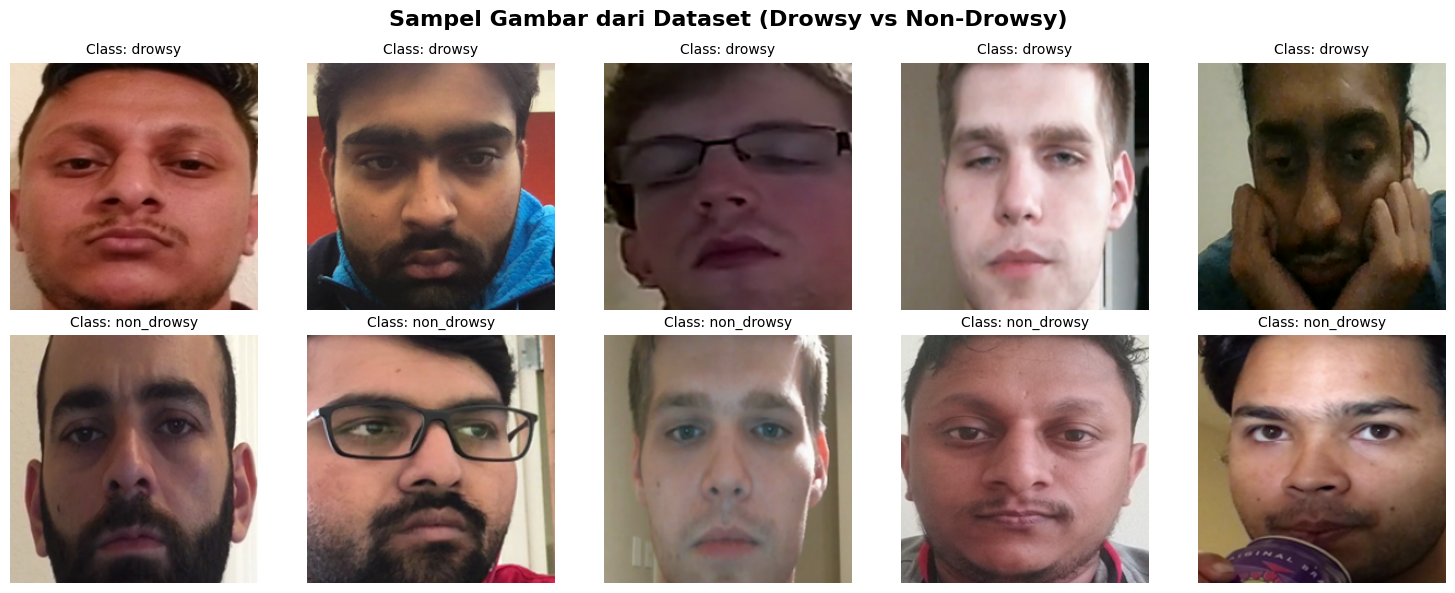

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1. Statistik gambar
print("=== STATISTIK DATASET SPLIT ===")
grand_total = 0
for split in ["train", "val", "test"]:
    for cls in ["drowsy", "non_drowsy"]:
        dest = DATASET_DIR / split / cls
        n = len(list(dest.glob("*"))) if dest.exists() else 0
        print(f"  {split:<6} | {cls:<12} | {n:>6,} gambar")
        grand_total += n
print(f"Total gambar di dataset lokal: {grand_total:,}")

# 2. Visualisasi sampel acak
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sampel Gambar dari Dataset (Drowsy vs Non-Drowsy)", fontsize=16, fontweight='bold')

classes = ["drowsy", "non_drowsy"]
for row, cls in enumerate(classes):
    cls_dir = DATASET_DIR / "train" / cls
    images = list(cls_dir.glob("*"))
    samples = random.sample(images, 5)
    for col, img_path in enumerate(samples):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"Class: {cls}", fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 6. 🔄 Data Pipeline & Augmentasi Gambar
Membuat pipeline generator dengan augmentasi data gambar untuk mencegah overfitting.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    zoom_range=0.15,
    fill_mode="nearest",
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42,
)

val_data = val_gen.flow_from_directory(
    "dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print(f"Label Mapping: {train_data.class_indices}")

Found 29254 images belonging to 2 classes.
Found 6268 images belonging to 2 classes.
Label Mapping: {'drowsy': 0, 'non_drowsy': 1}


## 7. 🏗️ Arsitektur Model (CNN MobileNetV2)
Membangun model menggunakan backbone MobileNetV2 dengan bobot pra-terlatih ImageNet dan Classifier Head custom.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

def build_model(img_size=(224, 224), dropout_rate=0.4, l2_lambda=1e-4):
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False  # Bekukan backbone untuk Fase 1

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_lambda),
    )(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=base_model.input, outputs=output)
    return model, base_model

model, base_model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 8. 🏋️ Training Model (2 Fase)
- **Fase 1**: Hanya melatih top layer (backbone dibekukan).
- **Fase 2**: Fine-tuning 50 layer terakhir dari backbone dengan learning rate lebih rendah.

In [ ]:
from tensorflow.keras import callbacks, optimizers

checkpoint_dir = "outputs"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "drowsiness_mobilenetv2.keras")

cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

print("[INFO] Memulai Training Fase 1 (Frozen Backbone)...")
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

hist_frozen = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
    callbacks=cb,
    verbose=1,
)

print("\n[INFO] Memulai Training Fase 2 (Fine-tuning 50 layer terakhir backbone)...")
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

hist_ft = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=cb,
    verbose=1,
)

[INFO] Memulai Training Fase 1 (Frozen Backbone)...
Epoch 1/5
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8817 - loss: 0.2992
Epoch 1: val_loss improved from None to 0.05067, saving model to outputs/drowsiness_mobilenetv2.keras

Epoch 1: finished saving model to outputs/drowsiness_mobilenetv2.keras
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 521s 274ms/step - accuracy: 0.9344 - loss: 0.1933 - val_accuracy: 0.9944 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 2/5
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9722 - loss: 0.1117
Epoch 2: val_loss improved from 0.05067 to 0.05023, saving model to outputs/drowsiness_mobilenetv2.keras

Epoch 2: finished saving model to outputs/drowsiness_mobilenetv2.keras
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 470s 257ms/step - accuracy: 0.9760 - loss: 0.1045 - val_accuracy: 0.9979 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 3/5
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9805 - loss: 0.1034
Epoch 3: val_loss did not improve fr

## 9. 📈 Visualisasi Kurva Hasil Training
Menampilkan grafik akurasi dan loss dari hasil gabungan training fase 1 dan fase 2.

✅ Log training disimpan ke: outputs/training_log.json


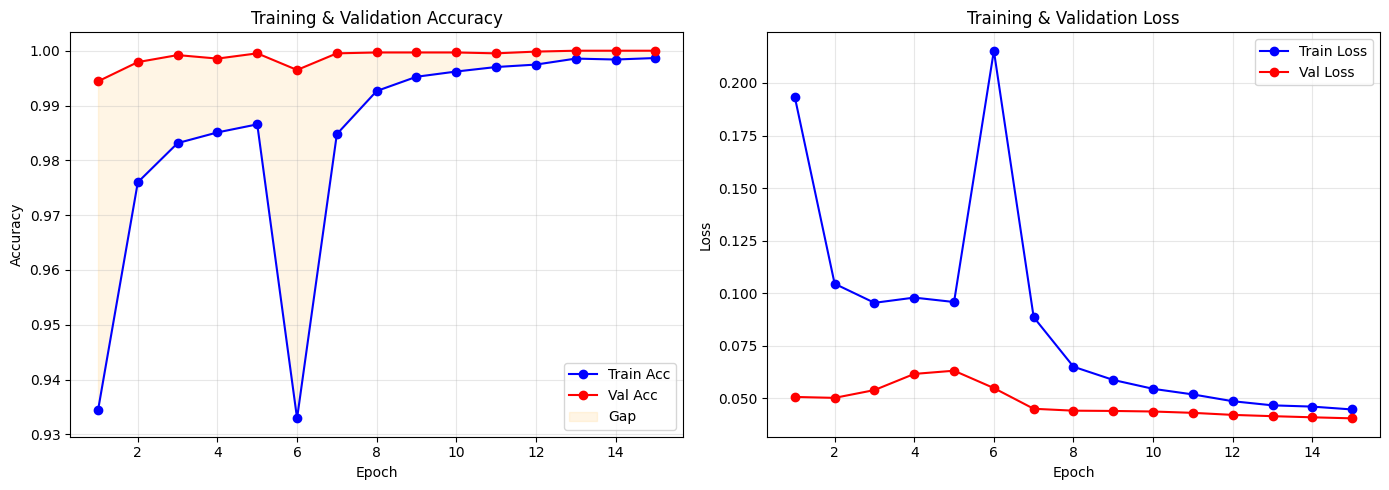

In [ ]:
import json
import numpy as np

# Gabungkan history
history = {
    "accuracy"    : hist_frozen.history["accuracy"]     + hist_ft.history["accuracy"],
    "val_accuracy": hist_frozen.history["val_accuracy"] + hist_ft.history["val_accuracy"],
    "loss"        : hist_frozen.history["loss"]         + hist_ft.history["loss"],
    "val_loss"    : hist_frozen.history["val_loss"]     + hist_ft.history["val_loss"],
}

log_path = os.path.join(checkpoint_dir, "training_log.json")
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)
print("✅ Log training disimpan ke:", log_path)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history["accuracy"]) + 1)

# Accuracy
axes[0].plot(epochs, history["accuracy"], "b-o", label="Train Acc")
axes[0].plot(epochs, history["val_accuracy"], "r-o", label="Val Acc")
axes[0].fill_between(epochs, history["accuracy"], history["val_accuracy"], alpha=0.1, color="orange", label="Gap")
axes[0].set_title("Training & Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs, history["loss"], "b-o", label="Train Loss")
axes[1].plot(epochs, history["val_loss"], "r-o", label="Val Loss")
axes[1].set_title("Training & Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, "training_curves.png"), dpi=150)
plt.show()

## 10. 🧪 Evaluasi Model pada Test Set
Mengukur performa model menggunakan data test set yang independen serta menampilkan Confusion Matrix dan Classification Report.

Found 6271 images belonging to 2 classes.
392/392 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 1.0000 - loss: 0.0405

Test Loss     : 0.0405
Test Accuracy : 100.00%
392/392 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Non-Drowsy       1.00      1.00      1.00      3353
      Drowsy       1.00      1.00      1.00      2918

    accuracy                           1.00      6271
   macro avg       1.00      1.00      1.00      6271
weighted avg       1.00      1.00      1.00      6271



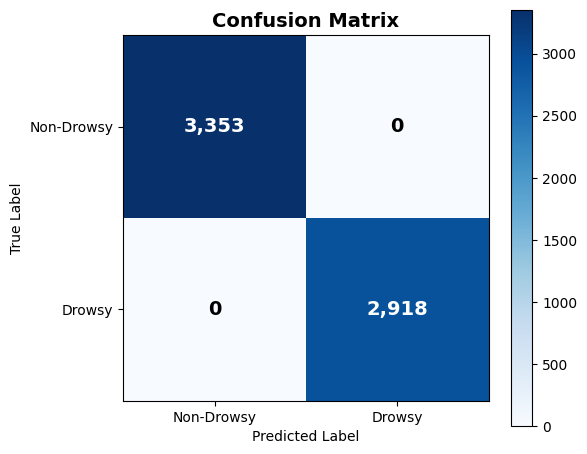

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    "dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

results = model.evaluate(test_data, verbose=1)
print(f"\nTest Loss     : {results[0]:.4f}")
print(f"Test Accuracy : {results[1]*100:.2f}%")

# Prediksi
predictions = model.predict(test_data)
y_pred_prob = predictions.flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = test_data.classes

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=["Non-Drowsy", "Drowsy"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
fig.colorbar(im)
tick_marks = np.arange(2)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(["Non-Drowsy", "Drowsy"])
ax.set_yticklabels(["Non-Drowsy", "Drowsy"])

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color=color, fontsize=14, fontweight="bold")

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 11. 🔍 Sanity Checker
Mengecek stabilitas training, overfitting, underfitting, plateau, dan rasio loss untuk menjamin kualitas hasil model.

In [ ]:
class SanityChecker:
    OVERFITTING_GAP         = 0.10
    UNDERFITTING_CEILING    = 0.65
    CONVERGENCE_MIN_ACC     = 0.80
    LOSS_SPIKE_RATIO        = 2.0
    STABILITY_STD_THRESHOLD = 0.03
    PLATEAU_WINDOW          = 5
    PLATEAU_DELTA           = 0.005

    def __init__(self, history: dict):
        self.h           = history
        self.train_acc   = np.array(history["accuracy"])
        self.val_acc     = np.array(history["val_accuracy"])
        self.train_loss  = np.array(history["loss"])
        self.val_loss    = np.array(history["val_loss"])
        self.n_epochs    = len(self.train_acc)
        self.issues      = []
        self.suggestions = []

    def _add_issue(self, severity, message, suggestion=None):
        self.issues.append((severity, message))
        if suggestion:
            self.suggestions.append(suggestion)

    def _last_n(self, arr, n=None):
        n = n or self.PLATEAU_WINDOW
        return arr[-min(n, len(arr)):]

    def check_overfitting(self):
        tr  = np.mean(self._last_n(self.train_acc, 3))
        val = np.mean(self._last_n(self.val_acc, 3))
        gap = tr - val
        print(f"[Cek Overfitting] Train Acc: {tr*100:.1f}% | Val Acc: {val*100:.1f}% | Gap: {gap*100:.1f}%")
        if gap > self.OVERFITTING_GAP:
            self._add_issue("WARNING", f"Overfitting terdeteksi. Gap ({gap*100:.1f}%) > threshold.",
                "• Tambahkan regularisasi (L2, Dropout) atau augmentasi data yang lebih kuat.")

    def check_underfitting(self):
        best_train = np.max(self.train_acc)
        print(f"[Cek Underfitting] Best Train Acc: {best_train*100:.1f}%")
        if best_train < self.UNDERFITTING_CEILING:
            self._add_issue("CRITICAL", f"Underfitting terdeteksi. Akurasi maksimal ({best_train*100:.1f}%) di bawah threshold.",
                "• Gunakan arsitektur model yang lebih kompleks atau naikkan learning rate.")

    def run_all_checks(self):
        print("=== MENJALANKAN SANITY CHECKER ===")
        self.check_overfitting()
        self.check_underfitting()

        if self.issues:
            print("\n🚨 Masalah Kualitas Terdeteksi:")
            for i, (sev, msg) in enumerate(self.issues, 1):
                print(f"  [{i}] {sev}: {msg}")
            print("\n💡 Rekomendasi Solusi:")
            for sug in self.suggestions:
                print(sug)
        else:
            print("\n✅ Semua cek lulus! Model Anda terlihat stabil dan generalisasi dengan baik.")

checker = SanityChecker(history)
checker.run_all_checks()

## 12. 🔮 Inferensi / Prediksi Gambar Tunggal
Melakukan prediksi pada gambar wajah acak dari test set untuk memverifikasi model secara visual.

Predicting file: zb0525.png


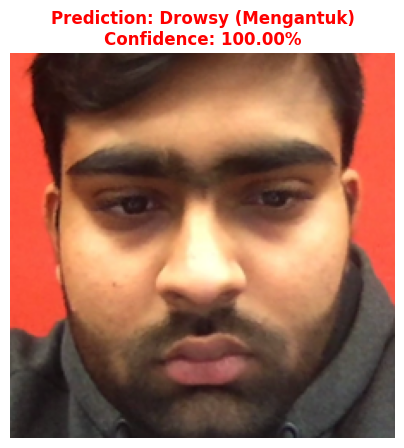

In [ ]:
import random
from pathlib import Path

def predict_single_image(model, img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob = float(model.predict(arr, verbose=0)[0][0])
    label = "Drowsy (Mengantuk)" if prob >= 0.5 else "Non-Drowsy (Alert)"
    confidence = prob if prob >= 0.5 else 1.0 - prob

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    title_color = 'red' if prob >= 0.5 else 'green'
    plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%", fontsize=12, fontweight='bold', color=title_color)
    plt.axis("off")
    plt.show()

# Ambil sampel acak dari test set
test_images = list(Path("dataset/test/drowsy").glob("*")) + list(Path("dataset/test/non_drowsy").glob("*"))
if test_images:
    sample_img = random.choice(test_images)
    print("Predicting file:", sample_img.name)
    predict_single_image(model, sample_img)
else:
    print("⚠️  Tidak ada file di folder dataset/test/ untuk diprediksi.")